In [1]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets scikit-learn matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 114.4 MB/s eta 0:00:00


In [2]:
import torch, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from peft import AdaLoraConfig, get_peft_model
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv("/content/drive/MyDrive/SST-2 (2 Classes).csv", encoding='ISO-8859-1')[['Text','Sentiment']].dropna()

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

train_texts, temp_texts, train_labels, temp_labels = train_test_split(df['Text'].tolist(), df['label'].tolist(),
                                                                      test_size=0.2, random_state=42, stratify=df['label'])
val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels,
                                                                  test_size=0.5, random_state=42, stratify=temp_labels)


Mounted at /content/drive


In [3]:
tok_distilbert = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tok_roberta    = AutoTokenizer.from_pretrained("roberta-base")

train_enc_distilbert = tok_distilbert(train_texts, truncation=True, padding=True, max_length=512)
val_enc_distilbert   = tok_distilbert(val_texts, truncation=True, padding=True, max_length=512)
test_enc_distilbert  = tok_distilbert(test_texts, truncation=True, padding=True, max_length=512)

train_enc_roberta = tok_roberta(train_texts, truncation=True, padding=True, max_length=512)
val_enc_roberta   = tok_roberta(val_texts, truncation=True, padding=True, max_length=512)
test_enc_roberta  = tok_roberta(test_texts, truncation=True, padding=True, max_length=512)

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels): self.encodings, self.labels = encodings, labels
    def __getitem__(self, idx): return {k: torch.tensor(v[idx]) for k,v in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx])}
    def __len__(self): return len(self.labels)

train_ds_distilbert, val_ds_distilbert, test_ds_distilbert = SentimentDataset(train_enc_distilbert,train_labels), SentimentDataset(val_enc_distilbert,val_labels), SentimentDataset(test_enc_distilbert,test_labels)
train_ds_roberta, val_ds_roberta, test_ds_roberta = SentimentDataset(train_enc_roberta,train_labels), SentimentDataset(val_enc_roberta,val_labels), SentimentDataset(test_enc_roberta,test_labels)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)*100
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"Accuracy":acc,"Precision":prec*100,"Recall":rec*100,"F1 Score":f1*100}


In [5]:
model_distilbert = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=len(label_encoder.classes_))
adalora_cfg_distilbert = AdaLoraConfig(init_r=12,target_r=4,beta1=0.85,beta2=0.85,tinit=200,tfinal=1000,deltaT=10,
                                       lora_alpha=32,lora_dropout=0.1,task_type="SEQ_CLS",
                                       target_modules=["q_lin","v_lin","out_lin"])
model_distilbert = get_peft_model(model_distilbert, adalora_cfg_distilbert)

args_distilbert = TrainingArguments(output_dir="./adalora-distilbert",eval_strategy="epoch",save_strategy="epoch",
                                    learning_rate=2e-4,per_device_train_batch_size=8,per_device_eval_batch_size=16,
                                    num_train_epochs=5,fp16=True,save_total_limit=2,load_best_model_at_end=True,
                                    metric_for_best_model="eval_loss",greater_is_better=False,report_to="none")

trainer_distilbert = Trainer(model=model_distilbert,args=args_distilbert,
                             train_dataset=train_ds_distilbert,eval_dataset=val_ds_distilbert,
                             compute_metrics=compute_metrics)

train_output_distilbert = trainer_distilbert.train()
metrics_distilbert = trainer_distilbert.evaluate(test_ds_distilbert)

# Predictions for confidence/similarity
preds_out = trainer_distilbert.predict(test_ds_distilbert)
probs = torch.nn.functional.softmax(torch.tensor(preds_out.predictions), dim=1)
confidence_distilbert = probs.max(dim=1).values.numpy().mean()*100
labels_onehot = np.eye(len(label_encoder.classes_))[test_ds_distilbert.labels]
similarity_distilbert = cosine_similarity(preds_out.predictions, labels_onehot).mean()*100

print(f"DistilBERT AdaLoRA Evaluation:")
print(f"Accuracy is: {metrics_distilbert['eval_Accuracy']:.2f}%")
print(f"Precision is: {metrics_distilbert['eval_Precision']:.2f}%")
print(f"Recall is: {metrics_distilbert['eval_Recall']:.2f}%")
print(f"F1 Score is: {metrics_distilbert['eval_F1 Score']:.2f}%")
print(f"Similarity Score is: {similarity_distilbert:.2f}%")
print(f"Confidence Score is: {confidence_distilbert:.2f}%")
print(f"Training Time (s): {train_output_distilbert.metrics['train_runtime']:.2f}")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,0.585300,0.349029,85.535900,84.130019,88.709677,86.359176
2,0.338100,0.325203,87.096774,88.114754,86.693548,87.398374
3,0.312000,0.318370,88.033299,87.573964,89.516129,88.534397
4,0.294700,0.333418,87.408949,85.578748,90.927419,88.172043
5,0.285500,0.303101,88.969823,90.625000,87.701613,89.139344


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in ver

DistilBERT AdaLoRA Evaluation:
Accuracy is: 88.77%
Precision is: 90.95%
Recall is: 86.92%
F1 Score is: 88.89%
Similarity Score is: -4.94%
Confidence Score is: 92.93%
Training Time (s): 303.81


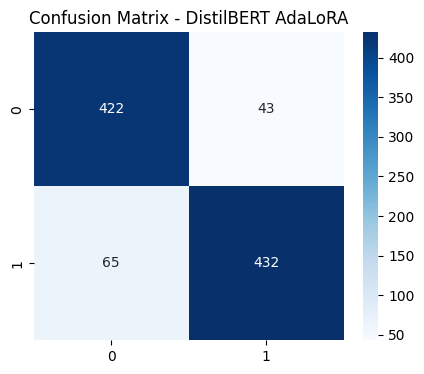

In [6]:
preds = np.argmax(preds_out.predictions,axis=1)
cm = confusion_matrix(test_ds_distilbert.labels,preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - DistilBERT AdaLoRA")
plt.show()


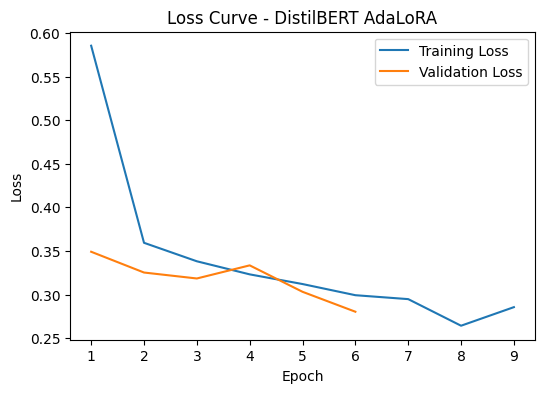

In [7]:
history = trainer_distilbert.state.log_history
train_loss = [x["loss"] for x in history if "loss" in x]
eval_loss = [x["eval_loss"] for x in history if "eval_loss" in x]

plt.figure(figsize=(6,4))
plt.plot(range(1,len(train_loss)+1),train_loss,label="Training Loss")
plt.plot(range(1,len(eval_loss)+1),eval_loss,label="Validation Loss")
plt.title("Loss Curve - DistilBERT AdaLoRA")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(); plt.show()


In [8]:
# Step 8: Train & Evaluate RoBERTa AdaLoRA

# Model + AdaLoRA config
model_roberta = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(label_encoder.classes_)
)

adalora_cfg_roberta = AdaLoraConfig(
    init_r=12,
    target_r=4,
    beta1=0.85,
    beta2=0.85,
    tinit=200,
    tfinal=1000,
    deltaT=10,
    lora_alpha=32,
    lora_dropout=0.1,
    task_type="SEQ_CLS",
    target_modules=["query","value","output.dense"]
)

model_roberta = get_peft_model(model_roberta, adalora_cfg_roberta)

# Training arguments
args_roberta = TrainingArguments(
    output_dir="./adalora-roberta",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    fp16=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none"
)

# Trainer
trainer_roberta = Trainer(
    model=model_roberta,
    args=args_roberta,
    train_dataset=train_ds_roberta,
    eval_dataset=val_ds_roberta,
    compute_metrics=compute_metrics
)

# Train + evaluate
train_output_roberta = trainer_roberta.train()
metrics_roberta = trainer_roberta.evaluate(test_ds_roberta)

# Predictions for confidence/similarity
preds_out_roberta = trainer_roberta.predict(test_ds_roberta)
probs_roberta = torch.nn.functional.softmax(torch.tensor(preds_out_roberta.predictions), dim=1)
confidence_roberta = probs_roberta.max(dim=1).values.numpy().mean()*100
labels_onehot_roberta = np.eye(len(label_encoder.classes_))[test_ds_roberta.labels]
similarity_roberta = cosine_similarity(preds_out_roberta.predictions, labels_onehot_roberta).mean()*100

# Print results in requested format
print(f"RoBERTa AdaLoRA Evaluation:")
print(f"Accuracy is: {metrics_roberta['eval_Accuracy']:.2f}%")
print(f"Precision is: {metrics_roberta['eval_Precision']:.2f}%")
print(f"Recall is: {metrics_roberta['eval_Recall']:.2f}%")
print(f"F1 Score is: {metrics_roberta['eval_F1 Score']:.2f}%")
print(f"Similarity Score is: {similarity_roberta:.2f}%")
print(f"Confidence Score is: {confidence_roberta:.2f}%")
print(f"Training Time (s): {train_output_roberta.metrics['train_runtime']:.2f}")


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,0.614400,0.227684,91.987513,91.159136,93.548387,92.338308
2,0.239300,0.337495,91.259105,88.289963,95.766129,91.876209
3,0.205700,0.251976,93.444329,93.386774,93.951613,93.668342
4,0.188900,0.267081,92.924037,91.153846,95.564516,93.307087
5,0.181600,0.248168,93.236212,93.013972,93.951613,93.480441


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in ver

RoBERTa AdaLoRA Evaluation:
Accuracy is: 92.72%
Precision is: 93.66%
Recall is: 92.15%
F1 Score is: 92.90%
Similarity Score is: 7.93%
Confidence Score is: 95.01%
Training Time (s): 673.65


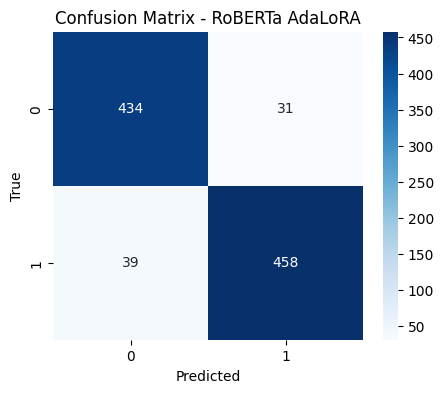

In [9]:
# Step 9: Confusion Matrix (RoBERTa AdaLoRA)

# Get predictions
preds_roberta = np.argmax(preds_out_roberta.predictions, axis=1)

# Build confusion matrix
cm_roberta = confusion_matrix(test_ds_roberta.labels, preds_roberta)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_roberta,
            annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - RoBERTa AdaLoRA")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


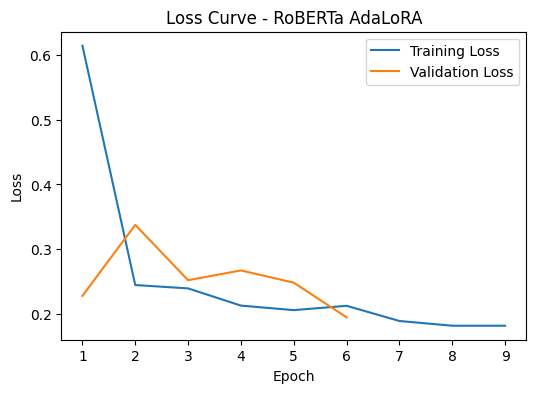

In [10]:
# Step 10: Training & Validation Loss Graph (RoBERTa AdaLoRA)

# Extract training history from the Trainer
history_roberta = trainer_roberta.state.log_history

# Collect training and validation losses
train_loss_roberta = [x["loss"] for x in history_roberta if "loss" in x]
eval_loss_roberta  = [x["eval_loss"] for x in history_roberta if "eval_loss" in x]

# Plot the curves by epoch
plt.figure(figsize=(6,4))
plt.plot(range(1, len(train_loss_roberta)+1), train_loss_roberta, label="Training Loss")
plt.plot(range(1, len(eval_loss_roberta)+1), eval_loss_roberta, label="Validation Loss")
plt.title("Loss Curve - RoBERTa AdaLoRA")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [11]:
# Step 11: Build Results Dictionaries

distilbert_results = {
    "Model": "AdaLoRA DistilBERT",
    "Accuracy": metrics_distilbert.get("eval_Accuracy", 0),
    "Precision": metrics_distilbert.get("eval_Precision", 0),
    "Recall": metrics_distilbert.get("eval_Recall", 0),
    "F1 Score": metrics_distilbert.get("eval_F1 Score", 0),
    "Similarity": similarity_distilbert,
    "Confidence": confidence_distilbert,
    "Training Time (s)": train_output_distilbert.metrics["train_runtime"],
    "Trainable Params": sum(p.numel() for p in model_distilbert.parameters() if p.requires_grad),
    "GPU Memory (GB)": torch.cuda.max_memory_allocated() / 1024**3
}

roberta_results = {
    "Model": "AdaLoRA RoBERTa",
    "Accuracy": metrics_roberta.get("eval_Accuracy", 0),
    "Precision": metrics_roberta.get("eval_Precision", 0),
    "Recall": metrics_roberta.get("eval_Recall", 0),
    "F1 Score": metrics_roberta.get("eval_F1 Score", 0),
    "Similarity": similarity_roberta,
    "Confidence": confidence_roberta,
    "Training Time (s)": train_output_roberta.metrics["train_runtime"],
    "Trainable Params": sum(p.numel() for p in model_roberta.parameters() if p.requires_grad),
    "GPU Memory (GB)": torch.cuda.max_memory_allocated() / 1024**3
}

# Step 12: Print Comparison Table
comparison_df = pd.DataFrame([distilbert_results, roberta_results])

# Format numeric columns
for col in ["Accuracy","Precision","Recall","F1 Score","Similarity","Confidence"]:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.2f}%" if isinstance(x,(int,float)) else x)

print("\n================================================================================")
print("COMPREHENSIVE MODEL COMPARISON")
print("================================================================================")
print(comparison_df.to_string(index=False))



COMPREHENSIVE MODEL COMPARISON
             Model Accuracy Precision Recall F1 Score Similarity Confidence  Training Time (s)  Trainable Params  GPU Memory (GB)
AdaLoRA DistilBERT   88.77%    90.95% 86.92%   88.89%     -4.94%     92.93%           303.8081            924122         1.196081
   AdaLoRA RoBERTa   92.72%    93.66% 92.15%   92.90%      7.93%     95.01%           673.6545           1809218         1.196081
